In [1]:
import torch
import os
from PIL import Image
from torchvision.transforms.functional import to_tensor, to_pil_image
from tkinter import Tk, filedialog
from basicsr.archs.rrdbnet_arch import RRDBNet
import matplotlib.pyplot as plt

In [2]:
Tk().withdraw()
img_path = filedialog.askopenfilename(filetypes=[("Image files", "*.jpg *.png *.jpeg")])
if not img_path:
    raise ValueError("No image selected")

img = Image.open(img_path).convert("RGB")
lr_tensor = to_tensor(img).unsqueeze(0)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    num_feat=64,
    num_block=23,
    num_grow_ch=32,
    scale=4
).to(device)

In [4]:
weights_path = "weights/RealESRGAN_x4plus.pth"
ckpt = torch.load(weights_path, map_location=device)

if isinstance(ckpt, dict):
    if "params_ema" in ckpt:
        model.load_state_dict(ckpt["params_ema"], strict=True)
    elif "params" in ckpt:
        model.load_state_dict(ckpt["params"], strict=True)
    elif "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"], strict=True)
    else:
        model.load_state_dict(ckpt, strict=True)
else:
    raise RuntimeError("error")

model.eval()

RRDBNet(
  (conv_first): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): RRDB(
      (rdb1): ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv5): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
      )
      (rdb2): ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), 

In [5]:
with torch.no_grad():
    sr = model(lr_tensor.to(device)).squeeze(0).clamp(0, 1).cpu()

sr_img = to_pil_image(sr)
filename = os.path.splitext(os.path.basename(img_path))[0]
out_path = os.path.join(os.path.dirname(img_path), f"{filename}_upscaled.png")
sr_img.save(out_path)

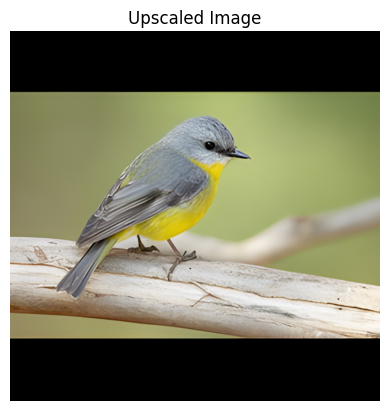

In [6]:
plt.imshow(sr_img)
plt.axis("off")
plt.title("Upscaled Image")
plt.show()